# RNN으로_금융앱리뷰_분석하기

In [24]:
# !pip install konlpy
# !pip install mecab-python3

In [25]:
from konlpy.tag import Mecab
import pandas as pd
import numpy as np
from tensorflow.keras.preprocessing.text import Tokenizer, text_to_word_sequence
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Embedding
from tensorflow.keras.utils import to_categorical

In [26]:
train_data = pd.read_csv("../05machine_learning/data/bank_app_reviews_train.csv")
train_data.head()

,리뷰일,평점,사용자리뷰,업체답변,은행명
0,2023-12-21,5,엄빠 폰에 설치해드렸는데 두분 다 쓰기 편하다고 하시네요 ㅎㅎ 저도 쓰고있음!,NaN,하나
1,2025-02-17,1,Cd기 축소 연장하려면 이 어플 깔라는데 왜 30퍼에서 안깔리는지 아니 애초에 슈퍼...,안녕하세요. 신한은행입니다.\n먼저 SOL사용에 불편을 드려 죄송합니다.\n어플의 ...,신한
2,2024-07-26,5,서비스가 통합되어 있어서 점점 사용빈도가 높아지네요.,고객님 안녕하세요! KB스타뱅킹을 이용해 주셔서 진심으로 감사드립니다. KB스타뱅킹...,국민
3,2024-09-01,1,카드 충천이 안됌,"안녕하세요. 전민구 님, 토스팀입니다. 남겨주신 내용만으로는 겪고계신 불편사항의 자...",토스
4,2023-11-13,1,알뜰폰 인증이 안돼요.....,"안녕하세요 헤이모두들안녕님, 우리은행입니다. 먼저 이용에 불편을 드려 매우 죄송합니...",우리


특수문자 제거 함수

In [27]:
import re

def clean_text(text):
    cleaned = re.sub(r'[^가-힣a-zA-Z0-9\s]','', text) #한글, 영문, 숫자
    cleaned = re.sub(r'\s+', ' ', cleaned) # 연속된 공백을 하나의 공백
    return cleaned.strip()

사용자 리뷰에서 특수문자 제거

In [28]:
train_data['사용자리뷰'] = train_data['사용자리뷰'].apply(clean_text)
train_data['사용자리뷰']

0                  엄빠 폰에 설치해드렸는데 두분 다 쓰기 편하다고 하시네요 저도 쓰고있음
1        Cd기 축소 연장하려면 이 어플 깔라는데 왜 30퍼에서 안깔리는지 아니 애초에 슈퍼...
2                             서비스가 통합되어 있어서 점점 사용빈도가 높아지네요
3                                                카드 충천이 안됌
4                                              알뜰폰 인증이 안돼요
                               ...                        
22241                                      어플 시작오류가 가끔 나네요
22242                              업데이트 후에 계좌이체하는 게 자주 튕겨요
22243                                                  굳굳굳
22244                                  오래시간 같이한 나의은행 든든합니다
22245    라이브 광고 전보다 더 안좋네 아무리 주기 싫어도 겨우 3원줄거면서 너무 쪼잔하게 ...
Name: 사용자리뷰, Length: 22246, dtype: object

is_good 컬럼 추가, 평점 4이상은 긍정: 1, 3이하는 부정: 0

In [29]:
train_data['is_good'] = train_data['평점'].apply(lambda x: 1 if x >=4 else 0)
train_data['is_good']

0        1
1        0
2        1
3        0
4        0
        ..
22241    0
22242    0
22243    1
22244    1
22245    0
Name: is_good, Length: 22246, dtype: int64

토큰화

In [30]:
train_data['사용자리뷰']

0                  엄빠 폰에 설치해드렸는데 두분 다 쓰기 편하다고 하시네요 저도 쓰고있음
1        Cd기 축소 연장하려면 이 어플 깔라는데 왜 30퍼에서 안깔리는지 아니 애초에 슈퍼...
2                             서비스가 통합되어 있어서 점점 사용빈도가 높아지네요
3                                                카드 충천이 안됌
4                                              알뜰폰 인증이 안돼요
                               ...                        
22241                                      어플 시작오류가 가끔 나네요
22242                              업데이트 후에 계좌이체하는 게 자주 튕겨요
22243                                                  굳굳굳
22244                                  오래시간 같이한 나의은행 든든합니다
22245    라이브 광고 전보다 더 안좋네 아무리 주기 싫어도 겨우 3원줄거면서 너무 쪼잔하게 ...
Name: 사용자리뷰, Length: 22246, dtype: object

In [31]:
mecab = Mecab()
mecab.morphs(train_data['사용자리뷰'][0])

['엄',
 '빠',
 '폰',
 '에',
 '설치',
 '해',
 '드렸',
 '는데',
 '두',
 '분',
 '다',
 '쓰',
 '기',
 '편하',
 '다고',
 '하',
 '시',
 '네요',
 '저',
 '도',
 '쓰',
 '고',
 '있',
 '음']

전체 문장을 토큰화 한 후 tokenized_docs에 저장

In [32]:
tokenized_docs = train_data['사용자리뷰'].apply(mecab.morphs)

In [33]:
tokenized_docs[2]

['서비스',
 '가',
 '통합',
 '되',
 '어',
 '있',
 '어서',
 '점점',
 '사용',
 '빈도',
 '가',
 '높',
 '아',
 '지',
 '네요']

단어 인덱스 생성

In [34]:
token = Tokenizer(lower=False)
token.fit_on_texts(tokenized_docs)
print(len(token.word_index))

13010


문장 벡터화

In [35]:
x = token.texts_to_sequences(tokenized_docs)
print(x[0])

[5400, 1682, 170, 11, 159, 37, 2292, 14, 301, 184, 28, 45, 19, 106, 123, 1, 76, 15, 216, 5, 45, 2, 10, 64]


가장 긴 문장의 길이 구하기

In [36]:
max_length = max([len(i) for i in x]) + 1
max_length

302

가장 긴 길이에 맞춰서 패딩
* RNN의 경우 패딩을 post로 주는 것이 더 좋음, 단어가 앞, 0이 뒤에 붙음
* Transformer계열은 위치 정보가 따로 있으므로 post, pre든 차이가 없음

In [37]:
X_padded = pad_sequences(x, maxlen=max_length, padding='post')
print(X_padded[1])

[7174   19 2404 1948    1  414    3   18   52  210 1258   51  521 1604
   42    6 3601  143   90 1518   11  725  553 1003  114    3   18   52
  435    2  725  923   11   94  221   18   29  485   51 4003 4523 4004
   58  277   77  725  923  923  251   28  210   13  366    4   39  250
 2830  332    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0 

In [38]:
X_padded.shape

(22246, 302)

In [39]:
y = train_data['is_good']
y.value_counts()

is_good
1    13240
0     9006
Name: count, dtype: int64

홀드아웃

In [40]:
# !pip install scikit-learn

In [41]:
from sklearn.model_selection import train_test_split

In [42]:
X_train, X_valid, y_train, y_valid = train_test_split(X_padded, y, test_size=0.3, stratify=y, random_state=42)

In [43]:
# 임베딩에 입력할 단어 수 추출
word_size = len(token.word_index)
print(word_size)

13010


In [44]:
import joblib

In [45]:
joblib.dump(token, "./model/bank_app_tokeizer.joblib")
joblib.dump(max_length, "./model/bank_app_max_length.joblib")

['./model/bank_app_max_length.joblib']

# 양방향 RNN 네트워크를 이용해 텍스트 분석

In [46]:
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Embedding, SimpleRNN, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [47]:
birnn = Sequential()
birnn.add(Input(shape=(max_length,)))
birnn.add(Embedding(input_dim=word_size, output_dim=64))
birnn.add(Bidirectional(SimpleRNN(128, return_sequences=False, activation='tanh')))
birnn.add(Dense(32, activation='relu'))
birnn.add(Dropout(0.5))
birnn.add(Dense(1, activation='sigmoid'))
birnn.summary()


I0000 00:00:1747963179.707622     521 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1347 MB memory:  -> device: 0, name: NVIDIA GeForce MX450, pci bus id: 0000:01:00.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 302, 64)        │       832,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 256)            │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         8,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 890,305 (3.40 MB)

 Trainable params: 890,305 (3.40 MB)

 Non-trainable params: 0 (0.00 B)

In [48]:
birnn.compile(loss='binary_crossentropy', optimizer='adam',
             metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])
early_stop = EarlyStopping(patience=10, restore_best_weights=True)
model_path = "./model/bank_app_review_birnn.keras"
checkpoint = ModelCheckpoint(filepath=model_path, monitor='val_loss',
                            save_best_only=True,
                            verbose=1)
birnn_history = birnn.fit(X_train, y_train, epochs=1000, batch_size=64,
                         validation_data=(X_valid, y_valid),
                         callbacks=[early_stop, checkpoint])


Epoch 1/1000


I0000 00:00:1747963182.343163   27742 service.cc:152] XLA service 0x7f04ec0d4640 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1747963182.343318   27742 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce MX450, Compute Capability 7.5
2025-05-23 10:19:42.407667: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1747963182.805956   27742 cuda_dnn.cc:529] Loaded cuDNN version 90300


  1/244 ━━━━━━━━━━━━━━━━━━━━ 18:54 5s/step - accuracy: 0.7188 - auc: 0.5779 - loss: 0.6591

I0000 00:00:1747963185.208431   27742 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


244/244 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - accuracy: 0.7905 - auc: 0.8405 - loss: 0.4765
Epoch 1: val_loss improved from inf to 0.32602, saving model to ./model/bank_app_review_birnn.keras
244/244 ━━━━━━━━━━━━━━━━━━━━ 36s 130ms/step - accuracy: 0.7907 - auc: 0.8408 - loss: 0.4762 - val_accuracy: 0.8674 - val_auc: 0.9320 - val_loss: 0.3260
Epoch 2/1000
244/244 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - accuracy: 0.8631 - auc: 0.9246 - loss: 0.3479
Epoch 2: val_loss did not improve from 0.32602
244/244 ━━━━━━━━━━━━━━━━━━━━ 30s 124ms/step - accuracy: 0.8632 - auc: 0.9247 - loss: 0.3478 - val_accuracy: 0.8773 - val_auc: 0.9467 - val_loss: 0.3404
Epoch 3/1000
244/244 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - accuracy: 0.9146 - auc: 0.9558 - loss: 0.2565
Epoch 3: val_loss improved from 0.32602 to 0.29363, saving model to ./model/bank_app_review_birnn.keras
244/244 ━━━━━━━━━━━━━━━━━━━━ 29s 118ms/step - accuracy: 0.9146 - auc: 0.9558 - loss: 0.2565 - val_accuracy: 0.8858 - val_auc: 0.9478 - val_loss: 0

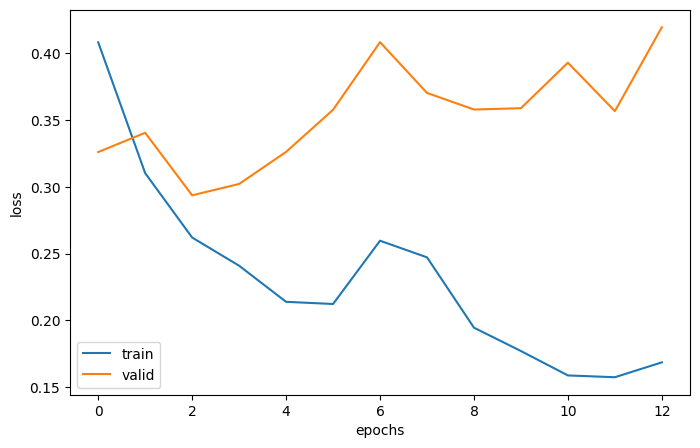

In [49]:
plt.figure(figsize=(8, 5))
plt.plot(birnn_history.history['loss'])
plt.plot(birnn_history.history['val_loss'])
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend(['train', 'valid'])
plt.show()

In [50]:
print(birnn.evaluate(X_valid, y_valid))

209/209 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.8914 - auc: 0.9504 - loss: 0.2842
[0.2936301827430725, 0.8858255743980408, 0.9478459358215332]


In [51]:
pred = birnn.predict(X_valid)
pred

209/209 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step


array([[0.9964605 ],
       [0.9476794 ],
       [0.06515086],
       ...,
       [0.92271876],
       [0.06940802],
       [0.97970206]], dtype=float32)

In [52]:
pred.shape

(6674, 1)

In [53]:
pred = pd.DataFrame(pred)

In [54]:
y_valid = pd.DataFrame(y_valid.reset_index(drop=True))
y_valid

,is_good
0,1
1,1
2,0
3,1
4,0
...,...
6669,0
6670,1
6671,1
6672,0


In [55]:
result = pd.concat([y_valid, pred], axis=1)
result

,is_good,0
0,1,0.996460
1,1,0.947679
2,0,0.065151
3,1,0.995079
4,0,0.043995
...,...,...
6669,0,0.030207
6670,1,0.947499
6671,1,0.922719
6672,0,0.069408


In [56]:
result.columns = ['is_good', 'pred']
result

,is_good,pred
0,1,0.996460
1,1,0.947679
2,0,0.065151
3,1,0.995079
4,0,0.043995
...,...,...
6669,0,0.030207
6670,1,0.947499
6671,1,0.922719
6672,0,0.069408


In [57]:
result['pred'] = result['pred'].apply(lambda x: 1 if x >= 0.5 else 0)

In [58]:
from sklearn.metrics import classification_report
print(classification_report(result['is_good'], result['pred']))

              precision    recall  f1-score   support

           0       0.85      0.88      0.86      2702
           1       0.91      0.89      0.90      3972

    accuracy                           0.89      6674
   macro avg       0.88      0.88      0.88      6674
weighted avg       0.89      0.89      0.89      6674



# LSTM과 CNN 조합 모델로 분석

In [59]:
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, GlobalMaxPooling1D

In [60]:
lstm_cnn = Sequential()
lstm_cnn.add(Input(shape=(max_length,)))
lstm_cnn.add(Embedding(input_dim=word_size, output_dim=128))
lstm_cnn.add(Dropout(0.3))
lstm_cnn.add(Conv1D(128, 5, padding='valid', activation='relu'))
lstm_cnn.add(MaxPooling1D(pool_size=4))
lstm_cnn.add(Conv1D(128, 5, padding='valid', activation='relu'))
lstm_cnn.add(MaxPooling1D(pool_size=4))
lstm_cnn.add(Bidirectional(LSTM(256, return_sequences=True)))
lstm_cnn.add(GlobalMaxPooling1D())
lstm_cnn.add(Dense(64, activation='relu'))
lstm_cnn.add(Dropout(0.3))
lstm_cnn.add(Dense(32, activation='relu'))
lstm_cnn.add(Dense(1, activation='sigmoid'))
lstm_cnn.summary()



Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 302, 128)       │     1,665,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 302, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 298, 128)       │        82,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 74, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 70, 128)        │        82,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 17, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 17, 512)        │       788,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 512)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,652,801 (10.12 MB)

 Trainable params: 2,652,801 (10.12 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/1000


2025-05-23 10:27:04.083125: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 2.05GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2025-05-23 10:27:04.151873: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 3.06GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.


244/244 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.7643 - auc: 0.8189 - loss: 0.4816

2025-05-23 10:27:22.717556: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 2.05GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.



Epoch 1: val_loss improved from inf to 0.27598, saving model to ./model/bank_app_review_lstm_cnn.keras
244/244 ━━━━━━━━━━━━━━━━━━━━ 28s 93ms/step - accuracy: 0.7646 - auc: 0.8193 - loss: 0.4812 - val_accuracy: 0.8930 - val_auc: 0.9529 - val_loss: 0.2760
Epoch 2/1000
244/244 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.9153 - auc: 0.9632 - loss: 0.2311
Epoch 2: val_loss improved from 0.27598 to 0.26900, saving model to ./model/bank_app_review_lstm_cnn.keras
244/244 ━━━━━━━━━━━━━━━━━━━━ 27s 111ms/step - accuracy: 0.9153 - auc: 0.9632 - loss: 0.2311 - val_accuracy: 0.8951 - val_auc: 0.9540 - val_loss: 0.2690
Epoch 3/1000
244/244 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.9400 - auc: 0.9772 - loss: 0.1756 
Epoch 3: val_loss did not improve from 0.26900
244/244 ━━━━━━━━━━━━━━━━━━━━ 27s 111ms/step - accuracy: 0.9400 - auc: 0.9772 - loss: 0.1756 - val_accuracy: 0.8875 - val_auc: 0.9491 - val_loss: 0.2835
Epoch 4/1000
244/244 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.9620 - auc:

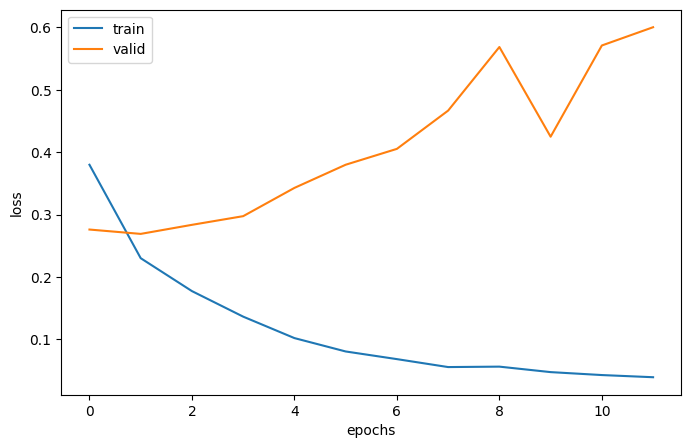

In [61]:
lstm_cnn.compile(loss='binary_crossentropy', optimizer='adam',
             metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])
early_stop = EarlyStopping(patience=10, restore_best_weights=True)
model_path = "./model/bank_app_review_lstm_cnn.keras"
checkpoint = ModelCheckpoint(filepath=model_path, monitor='val_loss',
                            save_best_only=True,
                            verbose=1)
lstm_cnn_history = lstm_cnn.fit(X_train, y_train, epochs=1000, batch_size=64,
                         validation_data=(X_valid, y_valid),
                         callbacks=[early_stop, checkpoint])
plt.figure(figsize=(8, 5))
plt.plot(lstm_cnn_history.history['loss'])
plt.plot(lstm_cnn_history.history['val_loss'])
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend(['train', 'valid'])
plt.show()

In [62]:
print(lstm_cnn.evaluate(X_valid, y_valid))

209/209 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.8997 - auc: 0.9552 - loss: 0.2643
[0.2689987123012543, 0.8951153755187988, 0.954012393951416]


In [63]:
pred = lstm_cnn.predict(X_valid)
pred

209/209 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step


array([[0.9880378 ],
       [0.99195004],
       [0.01752962],
       ...,
       [0.992721  ],
       [0.10302701],
       [0.977261  ]], dtype=float32)

In [64]:
pred.shape

(6674, 1)

In [65]:
pred = pd.DataFrame(pred)

In [66]:
y_valid = pd.DataFrame(y_valid.reset_index(drop=True))
y_valid

,is_good
0,1
1,1
2,0
3,1
4,0
...,...
6669,0
6670,1
6671,1
6672,0


In [67]:
result = pd.concat([y_valid, pred], axis=1)
result

,is_good,0
0,1,0.988038
1,1,0.991950
2,0,0.017530
3,1,0.985463
4,0,0.022870
...,...,...
6669,0,0.038798
6670,1,0.978619
6671,1,0.992721
6672,0,0.103027


In [68]:
result.columns = ['is_good', 'pred']
result

,is_good,pred
0,1,0.988038
1,1,0.991950
2,0,0.017530
3,1,0.985463
4,0,0.022870
...,...,...
6669,0,0.038798
6670,1,0.978619
6671,1,0.992721
6672,0,0.103027


In [69]:
result['pred'] = result['pred'].apply(lambda x: 1 if x > 0.5 else 0)

In [70]:
from sklearn.metrics import classification_report
print(classification_report(result['is_good'], result['pred']))

              precision    recall  f1-score   support

           0       0.85      0.90      0.87      2702
           1       0.93      0.89      0.91      3972

    accuracy                           0.90      6674
   macro avg       0.89      0.90      0.89      6674
weighted avg       0.90      0.90      0.90      6674



# Attention => GPT
* RNN이나 LSTM은 전체 문장을 기억
* 중요한 단어에만 집중

In [72]:
# !pip install attention

In [73]:
from attention import Attention

In [74]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling1D, LayerNormalization, MultiHeadAttention, Add

In [75]:
inputs = Input(shape=(max_length,))
x = Embedding(input_dim=word_size, output_dim=128)(inputs)
x = Dropout(0.3)(x)
# 양방향 LSTM
x = Bidirectional(LSTM(128, return_sequences=True))(x)
# 멀티헤드 어텐션
attn_output = MultiHeadAttention(num_heads=4, key_dim=64)(x, x)
attn_output = Dropout(0.3)(attn_output)
x = Add()([x, attn_output])
x = LayerNormalization()(x)
x = GlobalAveragePooling1D()(x)
# DNN
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
x = Dense(64, activation='relu')(x)
x = Dense(32, activation='relu')(x)
# 출력층
outputs = Dense(1, activation='sigmoid')(x)
attn_model = Model(inputs=inputs, outputs=outputs)
attn_model.summary()

Model: "functional_17"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 302)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_2         │ (None, 302, 128)  │  1,665,280 │ input_layer_2[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 302, 128)  │          0 │ embedding_2[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_2     │ (None, 302, 256)  │    263,168 │ dropout_3[0][0]   │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 302, 256)  │    263,168 │ bidirectional_2[… │
│ (MultiHeadAttentio… │                   │            │ bidirectional_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 302, 256)  │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 302, 256)  │          0 │ bidirectional_2[… │
│                     │                   │            │ dropout_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 302, 256)  │        512 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 256)       │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 128)       │     32,896 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 128)       │          0 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 64)        │      8,256 │ dropout_6[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 32)        │      2,080 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 1)         │         33 │ dense_7[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,235,393 (8.53 MB)

 Trainable params: 2,235,393 (8.53 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/2000
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 651ms/step - accuracy: 0.5916 - auc: 0.5737 - loss: 0.6792
Epoch 1: val_loss improved from inf to 0.54412, saving model to ./model/bank_app_review_attn_model.keras
122/122 ━━━━━━━━━━━━━━━━━━━━ 100s 797ms/step - accuracy: 0.5920 - auc: 0.5744 - loss: 0.6789 - val_accuracy: 0.7195 - val_auc: 0.8372 - val_loss: 0.5441
Epoch 2/2000
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 648ms/step - accuracy: 0.7729 - auc: 0.8371 - loss: 0.4802
Epoch 2: val_loss improved from 0.54412 to 0.31694, saving model to ./model/bank_app_review_attn_model.keras
122/122 ━━━━━━━━━━━━━━━━━━━━ 92s 751ms/step - accuracy: 0.7732 - auc: 0.8374 - loss: 0.4797 - val_accuracy: 0.8845 - val_auc: 0.9380 - val_loss: 0.3169
Epoch 3/2000
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 637ms/step - accuracy: 0.8205 - auc: 0.8852 - loss: 0.3979
Epoch 3: val_loss did not improve from 0.31694
122/122 ━━━━━━━━━━━━━━━━━━━━ 90s 741ms/step - accuracy: 0.8206 - auc: 0.8853 - loss: 0.3977 - val_accuracy: 0.8572 - val_a

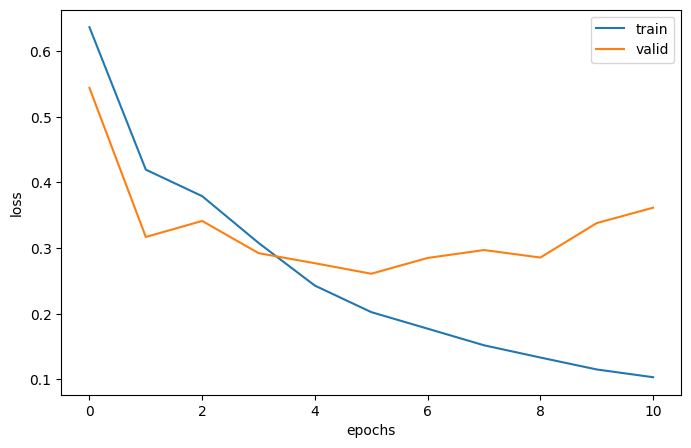

In [76]:
attn_model.compile(loss='binary_crossentropy', optimizer='adam',
             metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])
early_stop = EarlyStopping(patience=5, restore_best_weights=True)
model_path = "./model/bank_app_review_attn_model.keras"
checkpoint = ModelCheckpoint(filepath=model_path, monitor='val_loss',
                            save_best_only=True,
                            verbose=1)
attn_model_history = attn_model.fit(X_train, y_train, epochs=2000, batch_size=128,
                         validation_data=(X_valid, y_valid),
                         callbacks=[early_stop, checkpoint])
plt.figure(figsize=(8, 5))
plt.plot(attn_model_history.history['loss'])
plt.plot(attn_model_history.history['val_loss'])
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend(['train', 'valid'])
plt.show()

In [77]:
print(attn_model.evaluate(X_valid, y_valid))

209/209 ━━━━━━━━━━━━━━━━━━━━ 16s 78ms/step - accuracy: 0.9079 - auc: 0.9583 - loss: 0.2505
[0.26094087958335876, 0.8981120586395264, 0.9561560750007629]


In [78]:
pred = attn_model.predict(X_valid)
pred

209/209 ━━━━━━━━━━━━━━━━━━━━ 14s 66ms/step


array([[0.9871954 ],
       [0.9591133 ],
       [0.02396652],
       ...,
       [0.80951947],
       [0.06576983],
       [0.9849606 ]], dtype=float32)

In [79]:
pred.shape

(6674, 1)

In [80]:
pred = pd.DataFrame(pred)

In [81]:
y_valid = pd.DataFrame(y_valid.reset_index(drop=True))
y_valid

,is_good
0,1
1,1
2,0
3,1
4,0
...,...
6669,0
6670,1
6671,1
6672,0


In [82]:
result = pd.concat([y_valid, pred], axis=1)
result

,is_good,0
0,1,0.987195
1,1,0.959113
2,0,0.023967
3,1,0.988048
4,0,0.053854
...,...,...
6669,0,0.047776
6670,1,0.954184
6671,1,0.809519
6672,0,0.065770


In [83]:
result.columns = ['is_good', 'pred']
result

,is_good,pred
0,1,0.987195
1,1,0.959113
2,0,0.023967
3,1,0.988048
4,0,0.053854
...,...,...
6669,0,0.047776
6670,1,0.954184
6671,1,0.809519
6672,0,0.065770


In [84]:
result['pred'] = result['pred'].apply(lambda x: 1 if x > 0.5 else 0)

In [85]:
from sklearn.metrics import classification_report
print(classification_report(result['is_good'], result['pred']))

              precision    recall  f1-score   support

           0       0.85      0.91      0.88      2702
           1       0.94      0.89      0.91      3972

    accuracy                           0.90      6674
   macro avg       0.89      0.90      0.90      6674
weighted avg       0.90      0.90      0.90      6674

